In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str



In [3]:
def bmi_calculate(state: BMIState) -> BMIState:

    weight = state["weight_kg"]
    height = state["height_m"]

    bmi = weight / (height**2)
    state["bmi"] = round(bmi, 2)
    
    return state

In [4]:
def label_bmi(state: BMIState) -> BMIState:

    bmi = state["bmi"]

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state


In [5]:
graph = StateGraph(BMIState)

graph.add_node("BMI_Calculate", bmi_calculate)
graph.add_node("Label_BMI", label_bmi)

graph.add_edge(START, "BMI_Calculate")
graph.add_edge("BMI_Calculate", "Label_BMI")
graph.add_edge("Label_BMI", END)

workflow = graph.compile()

In [7]:
initial_state = {"weight_kg": 58, "height_m": 1.78}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 58, 'height_m': 1.78, 'bmi': 18.31, 'category': 'Underweight'}


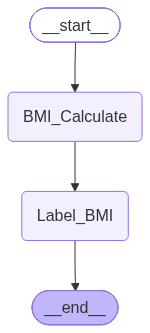

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())